# CNOT baseline time scan analysis

This notebook analyzes every update-time and cleanup-time combination
independently. For each combination it prints the scan summary and displays
the logical error-rate scan followed by its finite-size-scaling fit. A single
combined fit summary is displayed at the end.

In [18]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

from IPython.display import Markdown, display

from analysis_utils import (
    plot_finite_size_scaling_fit,
    display_fit_summary,
    fit_finite_size_scaling,
    load_ft_scan,
    plot_rate_scan,
)

RESULT_ROOT = Path("../results/baseline/ft/time_scan")
TIME_COMBINATIONS = [
    (1, 2),
    (1, 4),
    (2, 2),
    (2, 4),
    (3, 2),
    (3, 4),
]
P_VALUES = [
    0.010,
    0.011,
    0.012,
    0.013,
    0.014,
    0.015,
    0.016,
    0.017,
    0.018,
    0.019,
    0.020,
]
L_VALUES = [5, 7, 9, 13, 19]

# Change this positive integer to adjust the scaling-polynomial degree.
FIT_DEGREE = 4

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Per-combination analysis

### update_1T_cleanup_2T

Loaded 55 requested Ft files; ignored 0 files outside the requested lists
L values: [ 5  7  9 13 19]
p values: [0.01  0.011 0.012 0.013 0.014 0.015 0.016 0.017 0.018 0.019 0.02 ]
repeat counts:
 [[1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1]]


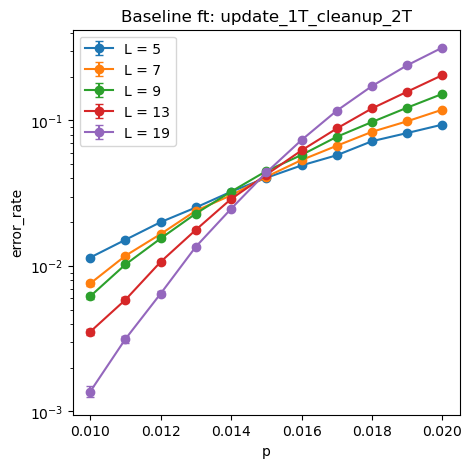

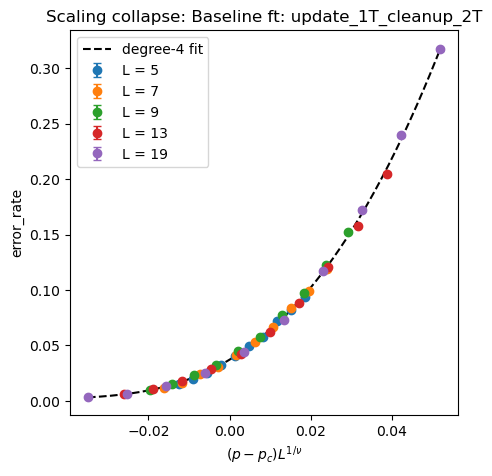

### update_1T_cleanup_4T

Loaded 55 requested Ft files; ignored 0 files outside the requested lists
L values: [ 5  7  9 13 19]
p values: [0.01  0.011 0.012 0.013 0.014 0.015 0.016 0.017 0.018 0.019 0.02 ]
repeat counts:
 [[1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1]]


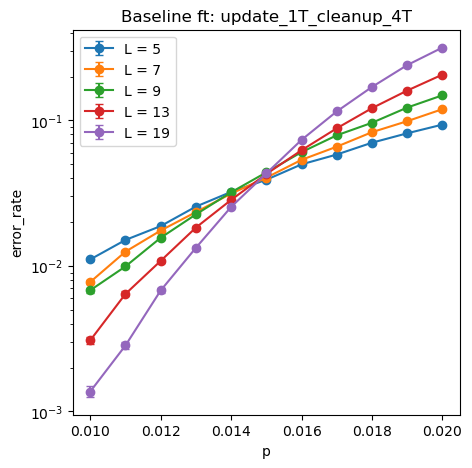

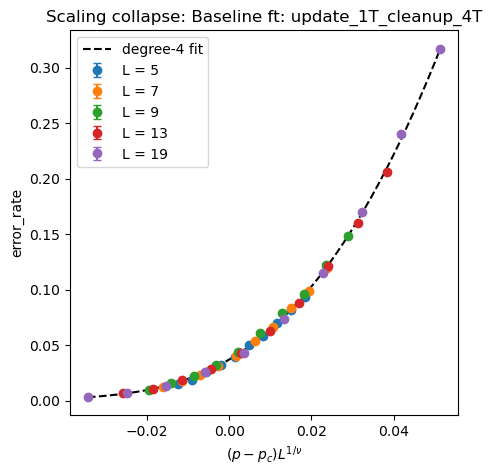

### update_2T_cleanup_2T

Loaded 55 requested Ft files; ignored 0 files outside the requested lists
L values: [ 5  7  9 13 19]
p values: [0.01  0.011 0.012 0.013 0.014 0.015 0.016 0.017 0.018 0.019 0.02 ]
repeat counts:
 [[1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1]]


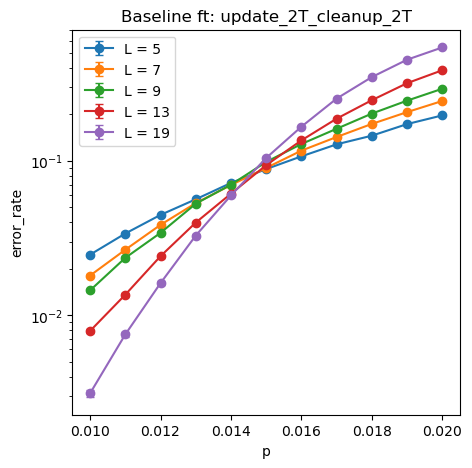

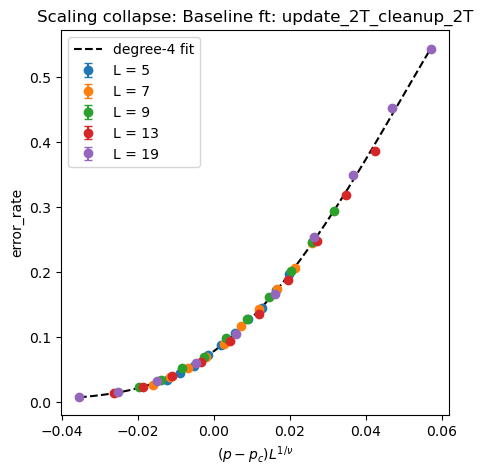

### update_2T_cleanup_4T

Loaded 55 requested Ft files; ignored 0 files outside the requested lists
L values: [ 5  7  9 13 19]
p values: [0.01  0.011 0.012 0.013 0.014 0.015 0.016 0.017 0.018 0.019 0.02 ]
repeat counts:
 [[1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1]]


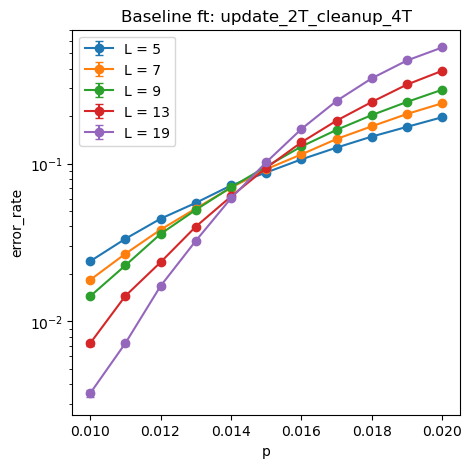

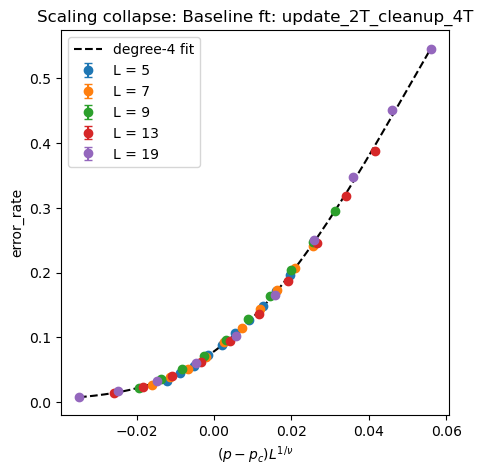

### update_3T_cleanup_2T

Loaded 55 requested Ft files; ignored 0 files outside the requested lists
L values: [ 5  7  9 13 19]
p values: [0.01  0.011 0.012 0.013 0.014 0.015 0.016 0.017 0.018 0.019 0.02 ]
repeat counts:
 [[1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1]]


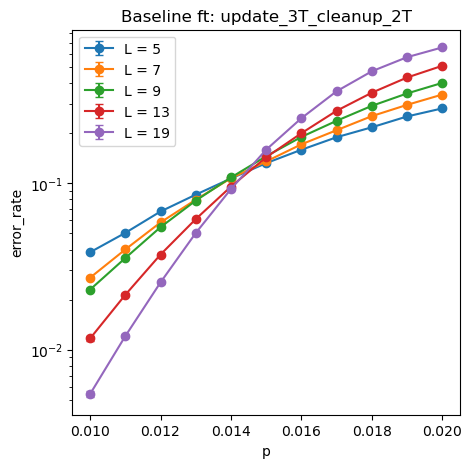

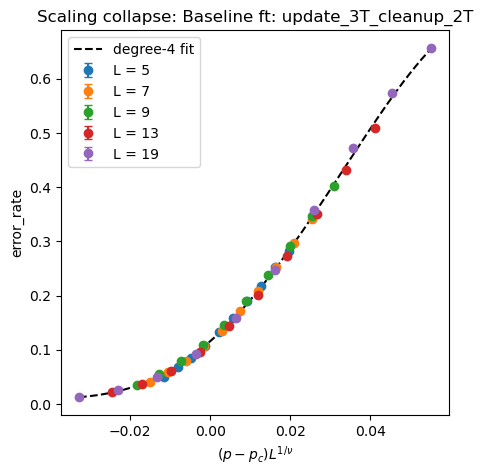

### update_3T_cleanup_4T

Loaded 55 requested Ft files; ignored 0 files outside the requested lists
L values: [ 5  7  9 13 19]
p values: [0.01  0.011 0.012 0.013 0.014 0.015 0.016 0.017 0.018 0.019 0.02 ]
repeat counts:
 [[1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1]]


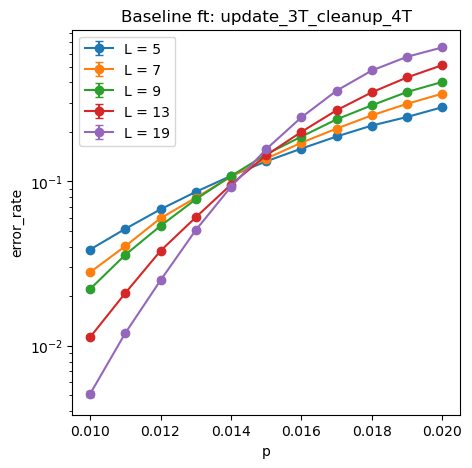

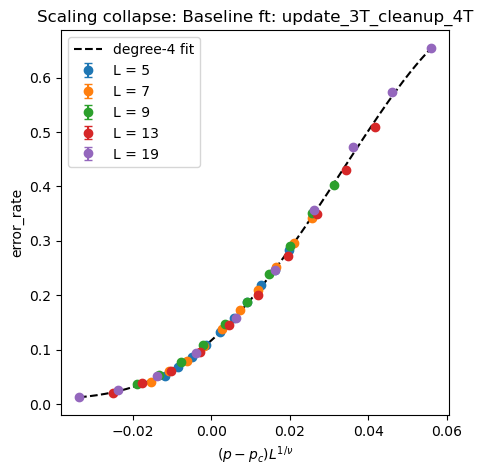

In [19]:
scans = {}
fits = {}

for update_time, cleanup_time in TIME_COMBINATIONS:
    combination = f"update_{update_time}T_cleanup_{cleanup_time}T"
    display(Markdown(f"### {combination}"))

    scan = load_ft_scan(
        RESULT_ROOT / combination,
        p_values=P_VALUES,
        L_values=L_VALUES,
        expected_repeats=1,
        result_pattern="2d_Ft*.txt",
        success_field="Ft",
        scan_label="Ft",
    )
    scans[combination] = scan
    scan.print_summary()

    plot_rate_scan(
        scan,
        title=f"Baseline ft: {combination}",
        ylabel="error_rate",
    )

    fit = fit_finite_size_scaling(
        scan,
        label=f"Baseline ft: {combination}",
        polynomial_degree=FIT_DEGREE,
    )
    fits[combination] = fit
    plot_finite_size_scaling_fit(fit, "error_rate")

## All-combination fit summary

In [20]:
display_fit_summary(
    list(fits.values()),
    title="Baseline fit summary: all timing combinations",
    include_degree=False,
    include_decimal_pc=False,
)

## Baseline fit summary: all timing combinations

| Timing and block | $p_c$ (%) | $\nu$ | $\chi^2 / \mathrm{dof}$ | fit $p$-value |
|---|---:|---:|---:|---:|
| Baseline ft: update_1T_cleanup_2T | 1.462(2) | 1.30(1) | 5.90 | 1.11e-31 |
| Baseline ft: update_1T_cleanup_4T | 1.461(2) | 1.31(1) | 5.57 | 4.5e-29 |
| Baseline ft: update_2T_cleanup_2T | 1.444(2) | 1.263(8) | 11.82 | 8.46e-81 |
| Baseline ft: update_2T_cleanup_4T | 1.445(2) | 1.273(8) | 10.81 | 3.91e-72 |
| Baseline ft: update_3T_cleanup_2T | 1.435(1) | 1.291(7) | 15.78 | 3.35e-115 |
| Baseline ft: update_3T_cleanup_4T | 1.438(1) | 1.281(6) | 15.03 | 1.21e-108 |